**CHAPTER 3**

TUGAS TEKS PROCESSING WEB SCARAPING USE HTTP & API

Di susun oleh:

Tabrizzi Aqlia — 25031554008

**Tugas 1 — Web Scraping menggunakan HTTP**

Web Scraping 50 Cafe Surabaya Via Maps

In [ ]:
!pip install playwright xlsxwriter
!playwright install chromium
!playwright install-deps chromium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.7 MB/s eta 0:00:00
186.8 MiB [] 0% 0.0s186.8 MiB [] 0% 199.0s186.8 MiB [] 0% 190.5s186.8 MiB [] 0% 92.5s186.8 MiB [] 0% 81.4s186.8 MiB [] 0% 76.4s186.8 MiB [] 0% 65.7s186.8 MiB [] 0% 56.3s186.8 MiB [] 0% 52.3s186.8 MiB [] 0% 52.0s186.8 MiB [] 0% 48.6s186.8 MiB [] 0% 45.5s186.8 MiB [] 0% 33.7s186.8 MiB [] 1% 27.3s186.8 MiB [] 1% 25.6s186.8 MiB [] 1% 21.9s186.8 MiB [] 1% 19.4s186.8 MiB [] 1% 18.1s186.8 MiB [] 2% 17.6s186.8 MiB [] 2% 16.9s186.8 MiB [] 2% 15.8s186.8 MiB [] 2% 14.8s186.8 MiB [] 2% 14.3s186.8 MiB [] 3% 14.3s186.8 MiB [] 3% 14.2s186.8 MiB [] 3% 14.3s186.8 MiB [] 3% 14.0s186.8 MiB [] 3% 13.4s186.8 MiB [] 3% 13.3s186.8 MiB [] 4% 13.2s186.8 MiB [] 4% 12.9s186.8 MiB [] 4% 12.8s186.8 MiB [] 4% 12.4s186.8 MiB [] 4% 12.5s186.8 MiB [] 4% 12.4s186.8 MiB [] 5% 12.0s186.8 MiB [] 5% 11.7s186.8 MiB [] 5% 11.6s186.8 MiB [] 5% 11.5s186.8 MiB [] 6% 11.5s

Mencari dan Mendownload Via XLSX

In [ ]:
import asyncio
import random
import sys
from playwright.async_api import async_playwright
from tqdm.notebook import tqdm
import pandas as pd

if sys.platform == "win32":
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())


async def run_masukmaps(kota: str, url_maps: str, jumlah_scroll: int = 15, target_maksimal: int = 50):

    user_agent_asli = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"
    print(f"[*] User Agent asli: {user_agent_asli}")

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True, args=['--disable-blink-features=AutomationControlled'])
        context = await browser.new_context(user_agent=user_agent_asli, viewport={"width": 1280, "height": 720})
        page = await context.new_page()

        try:

            print(f"[*] Mengunjungi google maps untuk kota: {kota}...")
            await page.goto(url_maps, wait_until="commit", timeout=60000)

            print("[*] Menunggu daftar cafe muncul...")
            await page.wait_for_selector('div[role="feed"]', timeout=30000)
            await page.wait_for_timeout(5000)

            panel_kiri = page.locator('div[role="feed"]')

            print("[*] memulai scroll otomatis pada panel kiri...")
            for i in tqdm(range(jumlah_scroll), desc="Scrolling"):
                await panel_kiri.evaluate("el => el.scrollBy(0, 3000)")
                jeda = random.uniform(3, 6)
                await asyncio.sleep(jeda)

            kartu_cafe = page.locator("a[href*='/maps/place/']")
            jumlah_terdeteksi = await kartu_cafe.count()
            print(f"\n[!] berhasil! total cafe yang terdeteksi setelah scroll: {jumlah_terdeteksi}")

            print("[*] Menyaring link cafe agar tidak duplikat...")
            link_unik = []
            for i in range(jumlah_terdeteksi):
                link = await kartu_cafe.nth(i).get_attribute("href")
                if link and link not in link_unik:
                    link_unik.append(link)

            print(f"[!] ditemukan {len(link_unik)} cafe unik setelah di saring.")

            print("[*] Memulai proses klik dan ekstraksi data detail...")
            daftar_data = []
            target_ambil = min(len(link_unik), target_maksimal)

            for i in tqdm(range(target_ambil), desc="Ekstraksi detail cafe"):
                try:
                    url_cafe = link_unik[i]

                    await page.goto(url_cafe, wait_until="commit", timeout=60000)
                    await asyncio.sleep(random.uniform(2, 4))

                    try:
                        nama = await page.locator("h1.DUwDvf").inner_text()
                    except:
                        nama = "tidak ada nama"
                    try:
                        alamat = await page.locator('button[data-item-id="address"]').inner_text()
                        alamat = alamat.replace("", "").strip()
                    except:
                        alamat = "tidak ada alamat"
                    try:
                        telepon = await page.locator('button[data-item-id^="phone:tel:"]').inner_text()
                    except:
                        telepon = "tidak ada telepon"
                    try:
                        rating_element = page.locator("div.F7nice span").first
                        rating = await rating_element.inner_text()
                        review_element = page.locator("div.F7nice").first
                        review_raw = await review_element.inner_text()
                        review = review_raw.split("(")[-1].replace(")", "").strip()
                    except Exception:
                        rating = "0.0"
                        review = "0"

                    try:
                        rating_bersih = float(rating.replace(",", "."))
                    except:
                        rating_bersih = 0.0

                    daftar_data.append({
                        "No": i + 1,
                        "Nama Cafe": nama,
                        "Rating": rating_bersih,
                        "Alamat": alamat,
                        "Telepon": telepon
                    })
                except Exception as e:
                    print(f"[X] Gagal mengambil detail ke-{i+1}: {e}")
                    continue

            df = pd.DataFrame(daftar_data)

            if not df.empty:

                nama_file = f"Result_Daftar_Cafe_{kota.title()}.xlsx"

                writer = pd.ExcelWriter(nama_file, engine='xlsxwriter')
                df.to_excel(writer, index=False, sheet_name='DataCafe')
                workbook = writer.book
                worksheet = writer.sheets['DataCafe']
                for idx, col in enumerate(df.columns):
                    max_len = df[col].astype(str).str.len().max()
                    worksheet.set_column(idx, idx, max_len + 5)
                writer.close()

                from google.colab import files
                files.download(nama_file)

                print(f"\n[V] SUKSES BESAR! file '{nama_file}' berhasil dibuat dengan {len(df)} data cafe.")
            else:
                print("[X] Data kosong! gagal menyimpan ke excel.")

            return df

        except Exception as e:
            print(f"error: {e}")
            return pd.DataFrame()
        finally:
            await browser.close()

url_surabaya = "https://www.google.com/maps/search/cafe+di+surabaya/@-7.2767195,112.7274157,11076m/data=!3m2!1e3!4b1?entry=ttu&g_ep=EgoyMDI2MDkxNi4wIKXMDSoASAFQAw%3D%3D"

df_hasil = await run_masukmaps(kota="surabaya", url_maps=url_surabaya)

[*] User Agent asli: Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36
[*] Mengunjungi google maps untuk kota: surabaya...
[*] Menunggu daftar cafe muncul...
[*] memulai scroll otomatis pada panel kiri...


Scrolling:   0%|          | 0/15 [00:00<?, ?it/s]


[!] berhasil! total cafe yang terdeteksi setelah scroll: 86
[*] Menyaring link cafe agar tidak duplikat...
[!] ditemukan 86 cafe unik setelah di saring.
[*] Memulai proses klik dan ekstraksi data detail...


Ekstraksi detail cafe:   0%|          | 0/50 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[V] SUKSES BESAR! file 'Result_Daftar_Cafe_Surabaya.xlsx' berhasil dibuat dengan 50 data cafe.


Melihat seluruh data

In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

display(df_hasil)

,No,Nama Cafe,Rating,Alamat,Telepon
0,1,Otewekopi,4.8,"\nTaman Apsari St No.25, Embong Kaliasin, Gen...",\n+62 813-2642-8553
1,2,Coffee TGC basra,4.5,"\nJl. Basuki Rahmat No.23, belakang McD, Kec....",\n+62 812-3778-7875
2,3,Fifteenth Cafe by Mark Design,4.8,"\nJl. Lombok No.15, Ngagel, Kec. Wonokromo, S...",\n+62 812-3415-3064
3,4,Redback Specialty Coffee,4.6,"\nJl. Raya Golf Graha Famili No.2 Blok K, Pra...",\n+62 811-3088-8988
4,5,Demandailing Cafe & Eatery,4.5,"\nJl. Klampis Jaya No.144, Klampis Ngasem, Ke...",\n+62 31 5995500
5,6,️ Kollabora | The Best Thematic Cafe & Restaur...,4.7,"\nJl. Raya Kupang Indah No.51, Sonokwijenan, ...",\n+62 811-3074-8787
6,7,Onetwothree Coffee&Eatery,4.8,"\nTaman Apsari St No.69, Embong Kaliasin, Gen...",\n+62 813-2642-8554
7,8,ADA APA DENGAN KOPI - AADK HAKIM,4.8,"\nArief Rahman Hakim No.181, Keputih, Kec. Su...",\n+62 896-5676-3456
8,9,Grandfather Coffeeshop,4.5,"\nJl. Kalasan No.25 I, Pacar Keling, Kec. Tam...",\n+62 822-5777-7025
9,10,ONNI House Surabaya,4.6,"\nJl. Opak No.56, Darmo, Kec. Wonokromo, Sura...",\n+62 821-4291-0990


**Tugas 2 — Web Scraping menggunakan API**

Web Scraping 120 Komen Kasus Karhutla Kalimantan - Via API Tiktok

In [ ]:
!pip install apify-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.2/160.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 13.2 MB/s eta 0:00:00


In [ ]:
from apify_client import ApifyClient

In [ ]:
client = ApifyClient("apify_api_DIivCDNfY4ClmcH5Wczo8Zyi9Ey6Ze19xM2S")

In [ ]:
run_input = {
    "commentsPerPost": 120,
    "excludePinnedPosts": False,
    "maxRepliesPerComment": 5,
    "postURLs": [
        "https://vt.tiktok.com/ZSqcuwEQm/"
    ],
    "resultsPerPage": 100
}

In [ ]:
run = client.actor(
    "clockworks/tiktok-comments-scraper"
).call(run_input=run_input)

[apify.tiktok-comments-scraper runId:ddLz4UUpzGiV90s2O] -> Status: RUNNING, Message: 
[apify.tiktok-comments-scraper runId:ddLz4UUpzGiV90s2O] -> 2026-09-28T12:30:08.854Z ACTOR: Pulling container image of build KuIVFI6IU118eMMQg from registry.
[apify.tiktok-comments-scraper runId:ddLz4UUpzGiV90s2O] -> 2026-09-28T12:30:08.857Z ACTOR: Creating container.
[apify.tiktok-comments-scraper runId:ddLz4UUpzGiV90s2O] -> 2026-09-28T12:30:08.933Z ACTOR: Starting container.
[apify.tiktok-comments-scraper runId:ddLz4UUpzGiV90s2O] -> 2026-09-28T12:30:08.941Z ACTOR: Running under "LIMITED_PERMISSIONS".
[apify.tiktok-comments-scraper runId:ddLz4UUpzGiV90s2O] -> 2026-09-28T12:30:09.002Z Running on architecture: x86_64
[apify.tiktok-comments-scraper runId:ddLz4UUpzGiV90s2O] -> 2026-09-28T12:30:09.005Z Will run command: xvfb-run -a -s "-ac -screen 0 1920x1080x24+32 -nolisten tcp" /bin/bash -o pipefail -c bash -c "    java         --enable-native-access=ALL-UNNAMED         -cp classes-test:classes-main:lib/

In [ ]:
dataset_id = run.default_dataset_id

items = list(
    client.dataset(dataset_id).iterate_items()
)

print("Jumlah data:", len(items))

Jumlah data: 120


In [ ]:
for i, item in enumerate(items, 1):
    print(f"{i}. {item.get('text', '')}")

1. kirain diera Prabowo bakal lebih baik, ternyata...🥺 🥺
2. di Kalimantan masih menderita, Wowo malah healing ke rusia.
3. Aku nangis mikirin hewan di dalam hutan😭😭😭
4. sawit.....oh.......sawit.
5. alhmdulillah gasyy , di Kalimantan Barat sebagain udh hujan, jujur aku nangis udh lama gk dengar suara hujan Alhamdulillah yaallah🥹🥹 , mungkin menurut kalian alay tapi bagi kami itu adalah sesuatu yg berharga
6. negara gagal dikelola penguasanya..anti kritik dan selalu rakyat jd korban..bodoh banget kita klo pemilu nanti masih dipilih..
7. ada daerah yg udah mulai turun hujan.. smoga juga Kalimantan scptnya turun hujan
8. y allah trunkan hjn untuk soudara2ku di kalimntn🥺
9. hanya di Indonesia punya hutan beribu2 hektar tapi tidak punya satupun pesawat pemadam kebakaran
10. yg salahin presiden org yg sakit hati 😹
11. Enak nya hidup di Indonesia, mencaci maki pemerintah, menghina presiden, rakyat nya masih hidup bahagia,, klo di Luar negeri mungkin kalian udah Meninggal / penjara..
12. Masih b

In [ ]:
for i, item in enumerate(items, 1):
    username = item.get("uniqueId", "")
    waktu = item.get("createTimeISO", "")
    komentar = item.get("text", "")

    print(f"{i}. @{username}")
    print(f"   Waktu: {waktu}")
    print(f"   Komentar: {komentar}")
    print()

1. @jack.ngibul
   Waktu: 2026-09-02T12:55:33.000Z
   Komentar: di Kalimantan masih menderita, Wowo malah healing ke rusia.

2. @b3w_real
   Waktu: 2026-09-02T12:56:49.000Z
   Komentar: kirain diera Prabowo bakal lebih baik, ternyata...🥺 🥺

3. @anindira1231
   Waktu: 2026-09-02T23:34:05.000Z
   Komentar: hanya di Indonesia punya hutan beribu2 hektar tapi tidak punya satupun pesawat pemadam kebakaran

4. @azmeng
   Waktu: 2026-09-03T00:14:41.000Z
   Komentar: zolim amat si prabowo ini semua demi nanam sawit

5. @ira17168
   Waktu: 2026-09-02T13:11:22.000Z
   Komentar: Aku nangis mikirin hewan di dalam hutan😭😭😭

6. @johanson06
   Waktu: 2026-09-02T12:56:24.000Z
   Komentar: sawit.....oh.......sawit.

7. @myyy249
   Waktu: 2026-09-03T01:15:51.000Z
   Komentar: mana nih influencer yg pd milih si gemoy, mana sepi lagi postingannya.

8. @mayorteddymaytedl
   Waktu: 2026-09-02T16:03:55.000Z
   Komentar: yg salahin presiden org yg sakit hati 😹

9. @user2294792220020
   Waktu: 2026-09-02T14:57:

DATA SCRAPING BERHASIL
Jumlah data: 120

Dataset berhasil dibuat.
Jumlah baris : 120
Jumlah kolom : 7


,No,Username,Waktu,Komentar,Like,Jumlah Reply,Panjang Komentar
0,1,b3w_real,02-09-2026 19:56:49,"kirain diera Prabowo bakal lebih baik, ternyat...",752,58.0,53
1,2,jack.ngibul,02-09-2026 19:55:33,"di Kalimantan masih menderita, Wowo malah heal...",2398,63.0,59
2,3,ira17168,02-09-2026 20:11:22,Aku nangis mikirin hewan di dalam hutan😭😭😭,554,16.0,42
3,4,johanson06,02-09-2026 19:56:24,sawit.....oh.......sawit.,34,4.0,25
4,5,ww.tiktokcomusername,05-09-2026 06:12:12,"alhmdulillah gasyy , di Kalimantan Barat sebag...",69,13.0,208
...,...,...,...,...,...,...,...
115,116,putra.pranata4,03-09-2026 21:40:09,si bodoh yang malang kau ini🤣🤣🤣🤣,0,NaN,32
116,117,bryantviolinnn,04-09-2026 14:01:55,"Tingkat bencana ini skalanya nasional, bahkan ...",0,NaN,371
117,118,bryantviolinnn,04-09-2026 14:02:44,dari bencana aceh kemaren aja sama. dia nolak ...,0,NaN,215
118,119,abcdefgggg1235648,02-09-2026 21:46:23,bisa dibuktikan gak omongan mu?? ada bukti gak??,1,NaN,48



CEK DATA KOSONG
No                   0
Username             0
Waktu                0
Komentar             0
Like                 0
Jumlah Reply        56
Panjang Komentar     0
dtype: int64

STATISTIK DATA
Jumlah komentar          : 120
Total Like               : 6306
Rata-rata Like           : 52.55
Total Reply              : 518.0
Rata-rata Reply          : 8.09
Rata-rata panjang teks   : 90.32

TOP 10 KOMENTAR BERDASARKAN LIKE


,Username,Waktu,Komentar,Like,Jumlah Reply
1,jack.ngibul,02-09-2026 19:55:33,"di Kalimantan masih menderita, Wowo malah heal...",2398,63.0
8,anindira1231,03-09-2026 06:34:05,hanya di Indonesia punya hutan beribu2 hektar ...,918,25.0
0,b3w_real,02-09-2026 19:56:49,"kirain diera Prabowo bakal lebih baik, ternyat...",752,58.0
2,ira17168,02-09-2026 20:11:22,Aku nangis mikirin hewan di dalam hutan😭😭😭,554,16.0
59,wodi32500,02-09-2026 23:26:04,98 ada krisis aja dia kabur ke Jordan 😂,242,NaN
6,monde2557,02-09-2026 20:12:18,ada daerah yg udah mulai turun hujan.. smoga j...,197,6.0
12,myyy249,03-09-2026 08:15:51,"mana nih influencer yg pd milih si gemoy, mana...",160,18.0
5,user2294792220020,02-09-2026 21:57:47,negara gagal dikelola penguasanya..anti kritik...,124,5.0
98,zyan.alfathir,02-09-2026 20:53:09,kenapa pak Prabowo yg salah?dasar dongo,90,NaN
4,ww.tiktokcomusername,05-09-2026 06:12:12,"alhmdulillah gasyy , di Kalimantan Barat sebag...",69,13.0



20 KATA PALING SERING MUNCUL


,Kata,Frekuensi
0,kebakaran,17
1,kalimantan,16
2,sawit,15
3,hujan,15
4,negara,14
5,gk,13
6,allah,12
7,prabowo,11
8,pemerintah,11
9,hutan,10


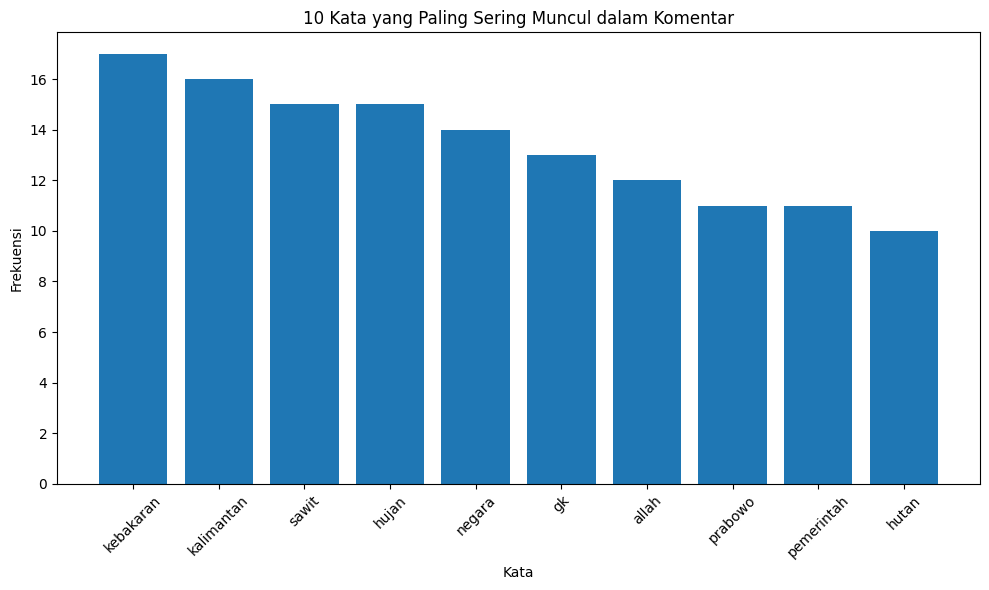

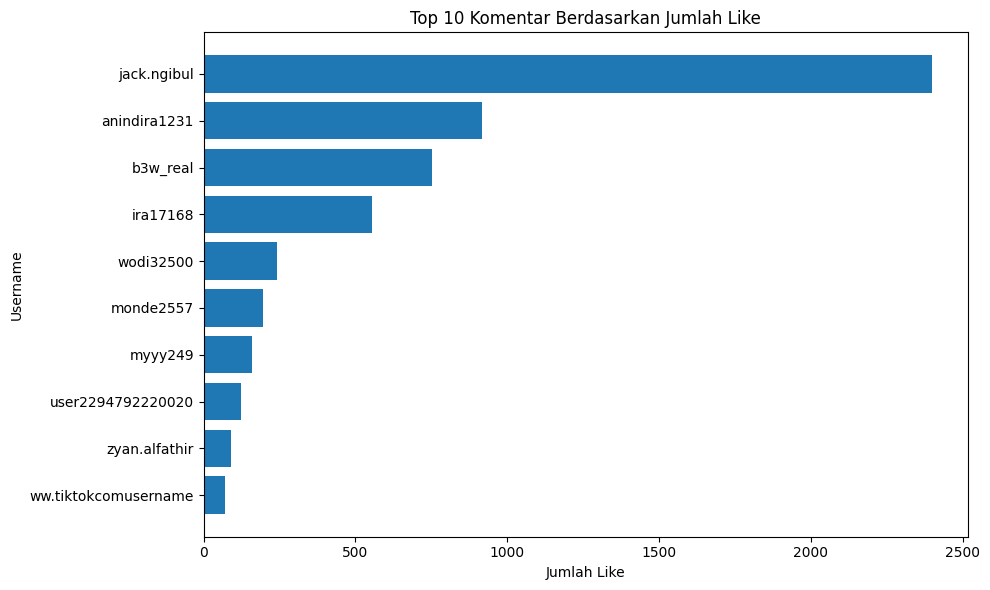

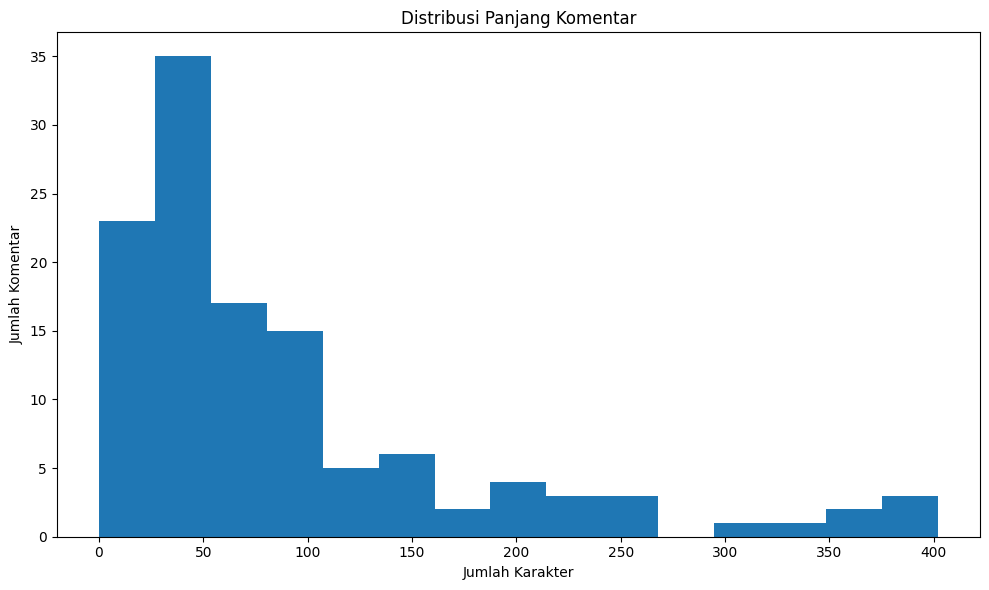


KOMENTAR DENGAN LIKE TERTINGGI
Username : jack.ngibul
Waktu    : 02-09-2026 19:55:33
Like     : 2398
Komentar : di Kalimantan masih menderita, Wowo malah healing ke rusia.

KOMENTAR TERPANJANG
Username : cecilianaluna
Waktu    : 06-09-2026 18:10:01
Panjang  : 402
Komentar : Kita boleh mengkritik pemerintah dan programnya, tapi jangan menyimpulkan sesuatu yang belum terbukti. Kalau ada dugaan pembakaran untuk pembukaan sawit, cari dulu siapa pelakunya dan bukti keterlibatannya. Begitu juga kasus MBG: kritik pemerintah soal pengawasan dan tata kelola itu sah, tetapi jangan otomatis menyimpulkan bahwa setiap kasus keracunan adalah tindakan atau kesalahan pribadi presiden.

EXPORT BERHASIL
File: analisis_komentar_tiktok.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime
from zoneinfo import ZoneInfo

# ==========================================
# 1. MENGAMBIL DATA DARI APIFY
# ==========================================

dataset_id = run.default_dataset_id

items = list(
    client.dataset(dataset_id).iterate_items()
)

print("=" * 60)
print("DATA SCRAPING BERHASIL")
print("=" * 60)
print("Jumlah data:", len(items))


# ==========================================
# 2. MEMBUAT DATASET
# ==========================================

data = []

for i, item in enumerate(items, 1):

    username = item.get("uniqueId", "")
    komentar = item.get("text", "")
    waktu = item.get("createTimeISO", "")

    like = item.get("diggCount", 0)
    reply = item.get("replyCommentTotal", 0)

    # Konversi waktu UTC ke WIB
    if waktu:
        try:
            dt = datetime.fromisoformat(
                waktu.replace("Z", "+00:00")
            )
            dt = dt.astimezone(
                ZoneInfo("Asia/Jakarta")
            )
            waktu_wib = dt.strftime(
                "%d-%m-%Y %H:%M:%S"
            )
        except:
            waktu_wib = waktu
    else:
        waktu_wib = ""

    # Panjang komentar
    panjang = len(komentar)

    data.append({
        "No": i,
        "Username": username,
        "Waktu": waktu_wib,
        "Komentar": komentar,
        "Like": like,
        "Jumlah Reply": reply,
        "Panjang Komentar": panjang
    })


# ==========================================
# 3. DATAFRAME
# ==========================================

df = pd.DataFrame(data)

print("\nDataset berhasil dibuat.")
print("Jumlah baris :", len(df))
print("Jumlah kolom :", len(df.columns))

display(df)


# ==========================================
# 4. CEK DATA KOSONG
# ==========================================

print("\n" + "=" * 60)
print("CEK DATA KOSONG")
print("=" * 60)

print(df.isnull().sum())


# ==========================================
# 5. STATISTIK DATA
# ==========================================

print("\n" + "=" * 60)
print("STATISTIK DATA")
print("=" * 60)

print("Jumlah komentar          :", len(df))
print("Total Like               :", df["Like"].sum())
print("Rata-rata Like           :", round(df["Like"].mean(), 2))
print("Total Reply              :", df["Jumlah Reply"].sum())
print("Rata-rata Reply          :", round(df["Jumlah Reply"].mean(), 2))
print("Rata-rata panjang teks   :", round(df["Panjang Komentar"].mean(), 2))


# ==========================================
# 6. TOP 10 KOMENTAR BERDASARKAN LIKE
# ==========================================

print("\n" + "=" * 60)
print("TOP 10 KOMENTAR BERDASARKAN LIKE")
print("=" * 60)

top_10 = df.sort_values(
    by="Like",
    ascending=False
).head(10)

display(
    top_10[
        [
            "Username",
            "Waktu",
            "Komentar",
            "Like",
            "Jumlah Reply"
        ]
    ]
)


# ==========================================
# 7. PREPROCESSING TEKS
# ==========================================

stopwords = {
    "yang", "dan", "atau", "ini", "itu",
    "ada", "untuk", "dari", "saya", "aku",
    "kamu", "dia", "nya", "banget", "bgt",
    "aja", "sih", "di", "ke", "dan",
    "ga", "gak", "nggak", "tidak",
    "ya", "yg", "dengan", "jadi",
    "udah", "sudah", "kok", "lah",
    "nih", "tuh", "pun"
}


def preprocessing(teks):

    teks = str(teks).lower()

    # Hapus URL
    teks = re.sub(
        r"http\S+|www\S+",
        "",
        teks
    )

    # Hapus username/mention
    teks = re.sub(
        r"@\w+",
        "",
        teks
    )

    # Hapus hashtag tetapi tetap mempertahankan katanya
    teks = re.sub(
        r"#",
        "",
        teks
    )

    # Hanya mengambil huruf
    teks = re.sub(
        r"[^a-zA-ZÀ-ÿ\s]",
        " ",
        teks
    )

    # Pecah menjadi kata
    kata = teks.split()

    # Hapus stopwords
    kata = [
        k for k in kata
        if k not in stopwords
    ]

    return kata


df["Kata Bersih"] = df["Komentar"].apply(
    preprocessing
)


# ==========================================
# 8. MENCARI 20 KATA PALING SERING MUNCUL
# ==========================================

semua_kata = []

for daftar_kata in df["Kata Bersih"]:
    semua_kata.extend(daftar_kata)

frekuensi = Counter(semua_kata)

top_kata = pd.DataFrame(
    frekuensi.most_common(20),
    columns=[
        "Kata",
        "Frekuensi"
    ]
)

print("\n" + "=" * 60)
print("20 KATA PALING SERING MUNCUL")
print("=" * 60)

display(top_kata)


# ==========================================
# 9. VISUALISASI TOP 10 KATA
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    top_kata["Kata"].head(10),
    top_kata["Frekuensi"].head(10)
)

plt.title(
    "10 Kata yang Paling Sering Muncul dalam Komentar"
)

plt.xlabel("Kata")
plt.ylabel("Frekuensi")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# ==========================================
# 10. VISUALISASI TOP 10 KOMENTAR BERDASARKAN LIKE
# ==========================================

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Username"].astype(str),
    top_10["Like"]
)

plt.title(
    "Top 10 Komentar Berdasarkan Jumlah Like"
)

plt.xlabel("Jumlah Like")
plt.ylabel("Username")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


# ==========================================
# 11. DISTRIBUSI PANJANG KOMENTAR
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["Panjang Komentar"],
    bins=15
)

plt.title(
    "Distribusi Panjang Komentar"
)

plt.xlabel("Jumlah Karakter")
plt.ylabel("Jumlah Komentar")

plt.tight_layout()

plt.show()


# ==========================================
# 12. KOMENTAR DENGAN LIKE TERTINGGI
# ==========================================

komentar_tertinggi = df.loc[
    df["Like"].idxmax()
]

print("\n" + "=" * 60)
print("KOMENTAR DENGAN LIKE TERTINGGI")
print("=" * 60)

print("Username :", komentar_tertinggi["Username"])
print("Waktu    :", komentar_tertinggi["Waktu"])
print("Like     :", komentar_tertinggi["Like"])
print("Komentar :", komentar_tertinggi["Komentar"])


# ==========================================
# 13. KOMENTAR TERPANJANG
# ==========================================

komentar_terpanjang = df.loc[
    df["Panjang Komentar"].idxmax()
]

print("\n" + "=" * 60)
print("KOMENTAR TERPANJANG")
print("=" * 60)

print("Username :", komentar_terpanjang["Username"])
print("Waktu    :", komentar_terpanjang["Waktu"])
print("Panjang  :", komentar_terpanjang["Panjang Komentar"])
print("Komentar :", komentar_terpanjang["Komentar"])


# ==========================================
# 14. EXPORT DATASET KE EXCEL
# ==========================================

df_export = df.drop(
    columns=["Kata Bersih"]
)

nama_file = "analisis_komentar_tiktok.xlsx"

df_export.to_excel(
    nama_file,
    index=False
)

print("\n" + "=" * 60)
print("EXPORT BERHASIL")
print("=" * 60)

print("File:", nama_file)


# ==========================================
# 15. DOWNLOAD EXCEL
# ==========================================

from google.colab import files

files.download(
    nama_file
)

WEB SCARAPING KOMENTAR INSTAGRAM


In [ ]:
!pip install -q apify-client pandas openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.7/158.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 21.5 MB/s eta 0:00:00


In [ ]:
from apify_client import ApifyClient
import pandas as pd

client = ApifyClient("apify_api_DIivCDNfY4ClmcH5Wczo8Zyi9Ey6Ze19xM2S")

run_input = {
    "targets": [
        "https://www.instagram.com/reel/DddTYs-pAuG/?stkn=MWVyNmVqbHZ1NnllZQ=="
    ],
    "commentsDesired": 50
}

print("🚀 Memulai scraping...")

run = client.actor(
    "herus13/instagram-comment-scraper"
).call(
    run_input=run_input
)

print("✅ Scraping selesai")

dataset_id = run.default_dataset_id
print("Dataset ID:", dataset_id)

items = []

for item in client.dataset(dataset_id).iterate_items():
    items.append(item)

print("Jumlah komentar:", len(items))

df = pd.DataFrame(items)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

display(df)

🚀 Memulai scraping...


[apify.instagram-comment-scraper runId:7AUShzuhxkKeTbqpU] -> Status: RUNNING, Message: 
[apify.instagram-comment-scraper runId:7AUShzuhxkKeTbqpU] -> 2026-09-21T20:47:31.693Z ACTOR: Pulling container image of build D8OxjJcLOhTLYskcY from registry.
[apify.instagram-comment-scraper runId:7AUShzuhxkKeTbqpU] -> 2026-09-21T20:47:31.696Z ACTOR: Creating container.
[apify.instagram-comment-scraper runId:7AUShzuhxkKeTbqpU] -> 2026-09-21T20:47:31.775Z ACTOR: Starting container.
[apify.instagram-comment-scraper runId:7AUShzuhxkKeTbqpU] -> 2026-09-21T20:47:31.776Z ACTOR: Running under "LIMITED_PERMISSIONS".
[apify.instagram-comment-scraper runId:7AUShzuhxkKeTbqpU] -> 2026-09-21T20:47:36.487Z Actor is running on the Apify platform, `disable_browser_sandbox` was changed to True.
[apify.instagram-comment-scraper runId:7AUShzuhxkKeTbqpU] -> 2026-09-21T20:47:36.491Z [apify] INFO  Initializing Actor ({"apify_sdk_version": "4.0.2", "apify_client_version": "3.2.0", "crawlee_version": "1.10.0", "python_ver

✅ Scraping selesai
Dataset ID: ODIPv3MwvPIW9Am3F
Jumlah komentar: 50


,comment,post_shortcode,post_url,owner_username,error,scraped_at
0,"{'pk': '17971352505155671', 'text': 'Bijinya Wowo yg satu itu', 'created_at': '2026-09-21T19:53:53Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'mmas.dwi', 'owner_id': '2200135618', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fjdf7-1.fna.fbcdn.net/v/t51.82787-19/726336781_18540357292079619_3608617090417090427_n.jpg?stp=dst-jpg_e0_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fjdf7-1.fna.fbcdn.net&_nc_cat=103&_nc_oc=Q6cZ2gF4xQkv2JCXYprcQPMZMKzc6zXeB2FPBA2Jz9Pxg_2x8dRlYvWkgqifUtvtDjb9AA0&_nc_ohc=JDmpUDMrNDwQ7kNvwFVlRBY&_nc_gid=DhZlLExIjKUUbEMpIu1wPA&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQJykeKiC5v4J1XSaxjJVxRS_ZMWM9nMMyrOsZy6zDjM8Q&oe=6AB75F0D&_nc_sid=24d064'}",DddTYs-pAuG,https://www.instagram.com/p/DddTYs-pAuG/,kasitau.info,None,2026-09-21T20:47:41+00:00
1,"{'pk': '18337912315259992', 'text': 'Telor ceplok itu mah bukan telor dadar min', 'created_at': '2026-09-21T19:02:52Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'ameel_mela', 'owner_id': '8037507106', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fjdf7-1.fna.fbcdn.net/v/t51.2885-19/426186725_895000362082602_8999177811684878019_n.jpg?stp=dst-jpg_e0_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fjdf7-1.fna.fbcdn.net&_nc_cat=106&_nc_oc=Q6cZ2gF4xQkv2JCXYprcQPMZMKzc6zXeB2FPBA2Jz9Pxg_2x8dRlYvWkgqifUtvtDjb9AA0&_nc_ohc=Jcj4uoQugB0Q7kNvwFtqW0j&_nc_gid=DhZlLExIjKUUbEMpIu1wPA&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQKNeNvczX-OMCqxYXnuveutM_w6ufJ5F_HkhDX6S7cXiA&oe=6AB76C29&_nc_sid=24d064'}",DddTYs-pAuG,https://www.instagram.com/p/DddTYs-pAuG/,kasitau.info,None,2026-09-21T20:47:41+00:00
2,"{'pk': '18090431720195179', 'text': 'Telor ceplok itu sih', 'created_at': '2026-09-21T18:57:07Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'karakova_time', 'owner_id': '39271853058', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fjdf7-1.fna.fbcdn.net/v/t51.2885-19/116015657_311182500291824_1564448140049315976_n.jpg?stp=dst-jpg_e0_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fjdf7-1.fna.fbcdn.net&_nc_cat=108&_nc_oc=Q6cZ2gF4xQkv2JCXYprcQPMZMKzc6zXeB2FPBA2Jz9Pxg_2x8dRlYvWkgqifUtvtDjb9AA0&_nc_ohc=aIM8WTzS1KoQ7kNvwE0CPD6&_nc_gid=DhZlLExIjKUUbEMpIu1wPA&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQIHiHAPhncei0g2R-pD1AdqfOkgRcXcEIpvg5fReV3vjQ&oe=6AB75EC6&_nc_sid=24d064'}",DddTYs-pAuG,https://www.instagram.com/p/DddTYs-pAuG/,kasitau.info,None,2026-09-21T20:47:41+00:00
3,"{'pk': '18094131329403503', 'text': 'Min itu bukan telur dadar', 'created_at': '2026-09-21T17:18:11Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'galih_purnama98', 'owner_id': '47605689034', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fjdf2-2.fna.fbcdn.net/v/t51.82787-19/746261221_18101144828585035_4625107223504125604_n.jpg?stp=dst-jpg_e0_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fjdf2-2.fna.fbcdn.net&_nc_cat=107&_nc_oc=Q6cZ2gF4xQkv2JCXYprcQPMZMKzc6zXeB2FPBA2Jz9Pxg_2x8dRlYvWkgqifUtvtDjb9AA0&_nc_ohc=n3_dbe8Va5MQ7kNvwEqCTsC&_nc_gid=DhZlLExIjKUUbEMpIu1wPA&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQLWjs5ZF6EO-Vk1Unmza8j_csw931z3yathfFatimmVWA&oe=6AB769DE&_nc_sid=24d064'}",DddTYs-pAuG,https://www.instagram.com/p/DddTYs-pAuG/,kasitau.info,None,2026-09-21T20:47:41+00:00
4,"{'pk': '18113188631044454', 'text': 'Telor ceplok', 'created_at': '2026-09-21T16:34:17Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'agustin_charming', 'owner_id': '7985163204', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fjdf7-1.fna.fbcdn.net/v/t51.2885-19/320882014_3284923845111968_8326008143479748459_n.jpg?stp=dst-jpg_e0_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI

In [ ]:
df["comment_length"] = df["comment"].astype(str).apply(len)
df["word_count"] = df["comment"].astype(str).apply(lambda x: len(x.split()))

print("Rata-rata panjang komentar:",
      round(df["comment_length"].mean(), 2), "karakter")

print("Rata-rata jumlah kata:",
      round(df["word_count"].mean(), 2), "kata")

display(df[["comment", "comment_length", "word_count"]])

Rata-rata panjang komentar: 797.52 karakter
Rata-rata jumlah kata: 26.92 kata


,comment,comment_length,word_count
0,"{'pk': '17971352505155671', 'text': 'Bijinya Wowo yg satu itu', 'created_at': '2026-09-21T19:53:53Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'mmas.dwi', 'owner_id': '2200135618', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fjdf7-1.fna.fbcdn.net/v/t51.82787-19/726336781_18540357292079619_3608617090417090427_n.jpg?stp=dst-jpg_e0_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fjdf7-1.fna.fbcdn.net&_nc_cat=103&_nc_oc=Q6cZ2gF4xQkv2JCXYprcQPMZMKzc6zXeB2FPBA2Jz9Pxg_2x8dRlYvWkgqifUtvtDjb9AA0&_nc_ohc=JDmpUDMrNDwQ7kNvwFVlRBY&_nc_gid=DhZlLExIjKUUbEMpIu1wPA&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQJykeKiC5v4J1XSaxjJVxRS_ZMWM9nMMyrOsZy6zDjM8Q&oe=6AB75F0D&_nc_sid=24d064'}",769,24
1,"{'pk': '18337912315259992', 'text': 'Telor ceplok itu mah bukan telor dadar min', 'created_at': '2026-09-21T19:02:52Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'ameel_mela', 'owner_id': '8037507106', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fjdf7-1.fna.fbcdn.net/v/t51.2885-19/426186725_895000362082602_8999177811684878019_n.jpg?stp=dst-jpg_e0_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fjdf7-1.fna.fbcdn.net&_nc_cat=106&_nc_oc=Q6cZ2gF4xQkv2JCXYprcQPMZMKzc6zXeB2FPBA2Jz9Pxg_2x8dRlYvWkgqifUtvtDjb9AA0&_nc_ohc=Jcj4uoQugB0Q7kNvwFtqW0j&_nc_gid=DhZlLExIjKUUbEMpIu1wPA&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQKNeNvczX-OMCqxYXnuveutM_w6ufJ5F_HkhDX6S7cXiA&oe=6AB76C29&_nc_sid=24d064'}",786,27
2,"{'pk': '18090431720195179', 'text': 'Telor ceplok itu sih', 'created_at': '2026-09-21T18:57:07Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'karakova_time', 'owner_id': '39271853058', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fjdf7-1.fna.fbcdn.net/v/t51.2885-19/116015657_311182500291824_1564448140049315976_n.jpg?stp=dst-jpg_e0_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fjdf7-1.fna.fbcdn.net&_nc_cat=108&_nc_oc=Q6cZ2gF4xQkv2JCXYprcQPMZMKzc6zXeB2FPBA2Jz9Pxg_2x8dRlYvWkgqifUtvtDjb9AA0&_nc_ohc=aIM8WTzS1KoQ7kNvwE0CPD6&_nc_gid=DhZlLExIjKUUbEMpIu1wPA&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQIHiHAPhncei0g2R-pD1AdqfOkgRcXcEIpvg5fReV3vjQ&oe=6AB75EC6&_nc_sid=24d064'}",768,23
3,"{'pk': '18094131329403503', 'text': 'Min itu bukan telur dadar', 'created_at': '2026-09-21T17:18:11Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'galih_purnama98', 'owner_id': '47605689034', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fjdf2-2.fna.fbcdn.net/v/t51.82787-19/746261221_18101144828585035_4625107223504125604_n.jpg?stp=dst-jpg_e0_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fjdf2-2.fna.fbcdn.net&_nc_cat=107&_nc_oc=Q6cZ2gF4xQkv2JCXYprcQPMZMKzc6zXeB2FPBA2Jz9Pxg_2x8dRlYvWkgqifUtvtDjb9AA0&_nc_ohc=n3_dbe8Va5MQ7kNvwEqCTsC&_nc_gid=DhZlLExIjKUUbEMpIu1wPA&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQLWjs5ZF6EO-Vk1Unmza8j_csw931z3yathfFatimmVWA&oe=6AB769DE&_nc_sid=24d064'}",778,24
4,"{'pk': '18113188631044454', 'text': 'Telor ceplok', 'created_at': '2026-09-21T16:34:17Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'agustin_charming', 'owner_id': '7985163204', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fjdf7-1.fna.fbcdn.net/v/t51.2885-19/320882014_3284923845111968_8326008143479748459_n.jpg?stp=dst-jpg_e0_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4zMjAuYzIifQ&_nc_ht=instagram.fjdf7-1.fna.fbcdn.net&_nc_cat=108&_nc_oc=Q6cZ2gF4xQkv2JCXYprcQPMZMKzc6zXeB2FPBA2Jz9Pxg_2x8dRlYvWkgqifUtvtDjb9AA0&_nc_ohc=cCXDt5hTKSUQ7kNvwE4clq4&_nc_gid=DhZlLExIjKUUbEMpIu1wPA&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQK3_Y09R5S7puJO6RPyburBstAAZd4mf8T--KbWgHz_Hw&oe=6AB781BD&_nc_sid=24d064'}",762,21
5,"{'pk': '18089651489689321', 'text': 'Pa

🚀 Memulai web scraping Instagram...


[apify.instagram-comment-scraper runId:zSnb1P7FNDw4OZKUp] -> Status: RUNNING, Message: 
[apify.instagram-comment-scraper runId:zSnb1P7FNDw4OZKUp] -> 2026-09-21T20:54:50.747Z ACTOR: Pulling container image of build D8OxjJcLOhTLYskcY from registry.
[apify.instagram-comment-scraper runId:zSnb1P7FNDw4OZKUp] -> 2026-09-21T20:54:56.296Z ACTOR: Creating container.
[apify.instagram-comment-scraper runId:zSnb1P7FNDw4OZKUp] -> 2026-09-21T20:54:56.442Z ACTOR: Starting container.
[apify.instagram-comment-scraper runId:zSnb1P7FNDw4OZKUp] -> 2026-09-21T20:54:56.445Z ACTOR: Running under "LIMITED_PERMISSIONS".
[apify.instagram-comment-scraper runId:zSnb1P7FNDw4OZKUp] -> 2026-09-21T20:55:01.631Z Actor is running on the Apify platform, `disable_browser_sandbox` was changed to True.
[apify.instagram-comment-scraper runId:zSnb1P7FNDw4OZKUp] -> 2026-09-21T20:55:01.657Z [apify] INFO  Initializing Actor ({"apify_sdk_version": "4.0.2", "apify_client_version": "3.2.0", "crawlee_version": "1.10.0", "python_ver

✅ Scraping selesai

DATASET
Jumlah komentar : 50
Jumlah kolom    : 6
Nama kolom      : ['comment', 'post_shortcode', 'post_url', 'owner_username', 'error', 'scraped_at']

Kolom komentar: comment

DATA QUALITY
Missing value:
comment              0
post_shortcode       0
post_url             0
owner_username       0
error               50
scraped_at           0
comment_original     0
comment_clean        0
comment_length       0
word_count           0
dtype: int64

Duplicate data: 0

TEXT STATISTICS
Rata-rata panjang komentar: 296.7 karakter
Rata-rata jumlah kata: 26.92 kata
Komentar terpanjang: 546 karakter
Komentar terpendek: 254 karakter

KOMENTAR LENGKAP


,comment_original,comment_clean,comment_length,word_count
0,"{'pk': '17971352505155671', 'text': 'Bijinya Wowo yg satu itu', 'created_at': '2026-09-21T19:53:53Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'mmas.dwi', 'owner_id': '2200135618', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fadb6-2.fna.fbcdn.net/v/t51.82787-19/726336781_18540357292079619_3608617090417090427_n.jpg?stp=dst-jpg_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fadb6-2.fna.fbcdn.net&_nc_cat=103&_nc_oc=Q6cZ2gGDxYDIjrFYX_dIY0q_mDWeaVq3VPzmomVgJK5GxE2UhIMaqVXJAUldcUYvpZXKuXI&_nc_ohc=JDmpUDMrNDwQ7kNvwFQzeMH&_nc_gid=PmHiQySUhvbP2MfKyX4Jsw&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQKJzRzALRcu5B-_QSCorjicUQArvK4niQHe1IUBIvsH2A&oe=6AB75F0D&_nc_sid=24d064'}","{'pk': '17971352505155671', 'text': 'Bijinya Wowo yg satu itu', 'created_at': '2026-09-21T19:53:53Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'mmas.dwi', 'owner_id': '2200135618', 'owner_is_verified': False, 'owner_profile_pic_url': '",269,24
1,"{'pk': '18337912315259992', 'text': 'Telor ceplok itu mah bukan telor dadar min', 'created_at': '2026-09-21T19:02:52Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'ameel_mela', 'owner_id': '8037507106', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fadb6-3.fna.fbcdn.net/v/t51.2885-19/426186725_895000362082602_8999177811684878019_n.jpg?stp=dst-jpg_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fadb6-3.fna.fbcdn.net&_nc_cat=106&_nc_oc=Q6cZ2gGDxYDIjrFYX_dIY0q_mDWeaVq3VPzmomVgJK5GxE2UhIMaqVXJAUldcUYvpZXKuXI&_nc_ohc=Jcj4uoQugB0Q7kNvwGFwNKp&_nc_gid=PmHiQySUhvbP2MfKyX4Jsw&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQKvhuWli8_IZTjr2SjbEZ4g7W4ATWbk1RKuCcecAcss1A&oe=6AB76C29&_nc_sid=24d064'}","{'pk': '18337912315259992', 'text': 'Telor ceplok itu mah bukan telor dadar min', 'created_at': '2026-09-21T19:02:52Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'ameel_mela', 'owner_id': '8037507106', 'owner_is_verified': False, 'owner_profile_pic_url': '",289,27
2,"{'pk': '18090431720195179', 'text': 'Telor ceplok itu sih', 'created_at': '2026-09-21T18:57:07Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'karakova_time', 'owner_id': '39271853058', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fadb6-5.fna.fbcdn.net/v/t51.2885-19/116015657_311182500291824_1564448140049315976_n.jpg?stp=dst-jpg_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fadb6-5.fna.fbcdn.net&_nc_cat=108&_nc_oc=Q6cZ2gGDxYDIjrFYX_dIY0q_mDWeaVq3VPzmomVgJK5GxE2UhIMaqVXJAUldcUYvpZXKuXI&_nc_ohc=aIM8WTzS1KoQ7kNvwGfnv5J&_nc_gid=PmHiQySUhvbP2MfKyX4Jsw&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQKpzonvJMJDm7tQbJJ2vsoaP-V1r7e7xgTNdVDWMFMxaQ&oe=6AB75EC6&_nc_sid=24d064'}","{'pk': '18090431720195179', 'text': 'Telor ceplok itu sih', 'created_at': '2026-09-21T18:57:07Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'karakova_time', 'owner_id': '39271853058', 'owner_is_verified': False, 'owner_profile_pic_url': '",271,23
3,"{'pk': '18094131329403503', 'text': 'Min itu bukan telur dadar', 'created_at': '2026-09-21T17:18:11Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'galih_purnama98', 'owner_id': '47605689034', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fadb6-1.fna.fbcdn.net/v/t51.82787-19/746261221_18101144828585035_4625107223504125604_n.jpg?stp=dst-jpg_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fadb6-1.fna.fbcdn.net&_nc_cat=107&_nc_oc=Q6cZ2gGDxYDIjrFYX_dIY0q_mDWeaVq3VPzmomVgJK5GxE2UhIMaqVXJAUldcUYvpZXKuXI&_nc_ohc=n3_dbe8Va5MQ7kNvwFSPWVL&_nc_gid=PmHiQySUhvbP2MfKyX4Jsw&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQIVWQNVAM2qnHdVcEntUw2qAvTPRu19bpxQNmdcamKVrw&oe=6


TOP 10 KATA
owner: 200
count: 100
none: 100
text: 50
created: 50
2026: 50
like: 50
reply: 50
parent: 50
username: 50


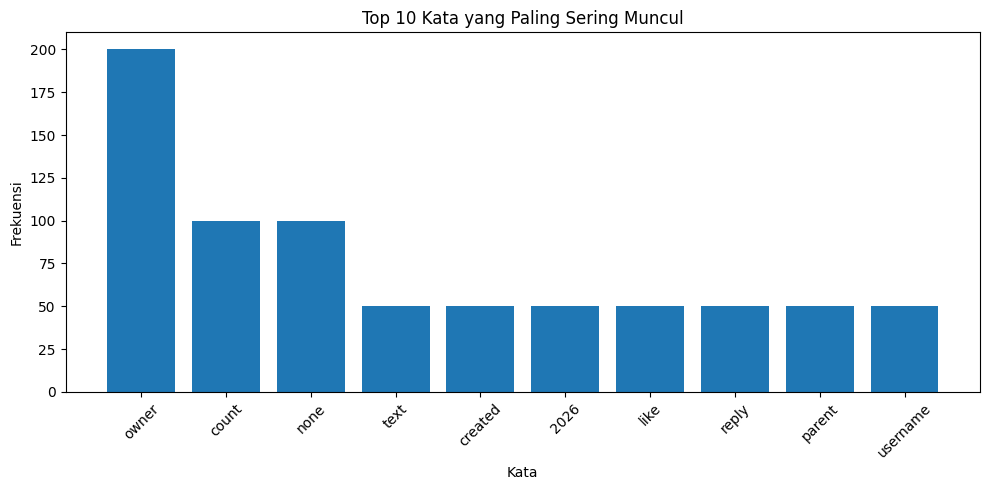

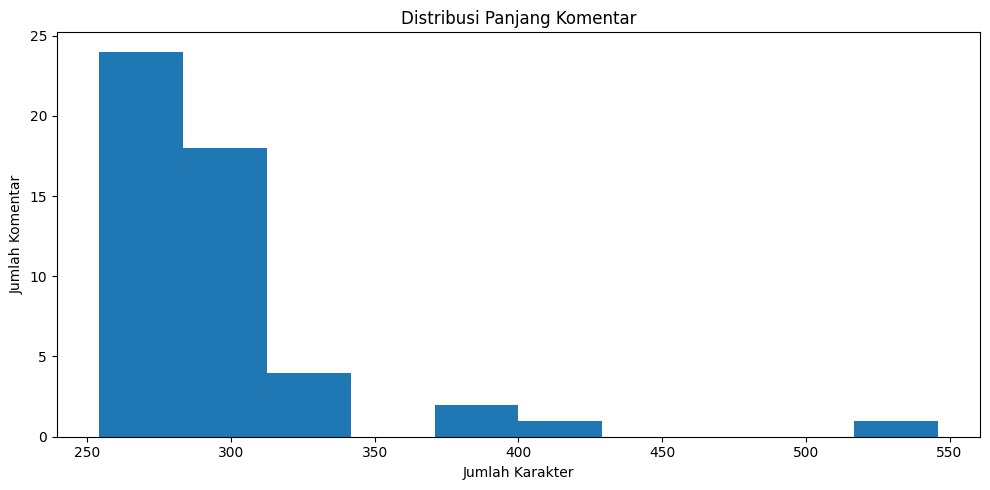

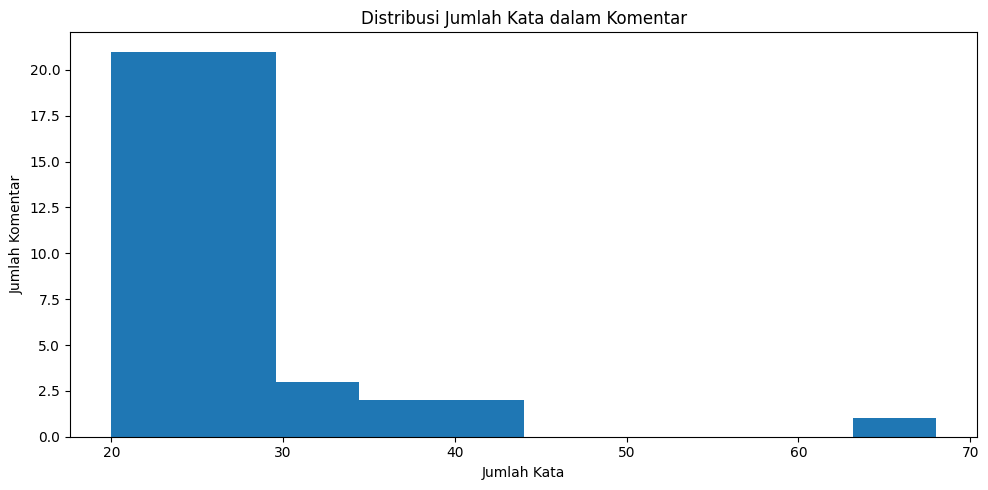


TOP KOMENTAR TERPANJANG


,comment_original,comment_length,word_count
17,"{'pk': '18143226880603393', 'text': 'Tau gak sebelum gunung ini meletus, dia mau ngajarin kyak mna cara buat telor mata sapi, dan gunung Krakatau mengajar prabowo lihat aku menciptakan mbg dan tidak mahal, tapi buat kelen ketakutan para koruptor😂😂, seandainya aku meledak lebih dahsyat lagi maka kln pada mati semua di pulau Jawa 😂😭', 'created_at': '2026-09-21T12:59:47Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'muhammadhamsy', 'owner_id': '70219554860', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fadb6-5.fna.fbcdn.net/v/t51.2885-19/465312884_990514306166612_5754812047511950324_n.jpg?stp=dst-jpg_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby42MTIuYzIifQ&_nc_ht=instagram.fadb6-5.fna.fbcdn.net&_nc_cat=108&_nc_oc=Q6cZ2gHKXCIW9RPWDAT75aYiSLiQko9sTfSoMM61PZlLyiVKcGJZ0qvZWsFsx4poxfglpeo&_nc_ohc=hIF_F1MelW8Q7kNvwFMEB06&_nc_gid=y_LN-U9WVskyQn66i-o83g&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQKHOXEpQ9cBCUl19RE19ElXeJzzqBomPElOiNLtEaJw8g&oe=6AB781F0&_nc_sid=24d064'}",546,68
5,"{'pk': '18089651489689321', 'text': 'Padahal hanya mau buat telor ceplok!!!tapi berhasil membuat panik pulau2 terdekat dan negara2 tetangga🤣🤣🤣udah ya jangan buat kepanikan lagi ...waktunya untuk tdur yg lelap!!!', 'created_at': '2026-09-21T16:26:54Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'baimkell', 'owner_id': '39673810522', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fjog2-1.fna.fbcdn.net/v/t51.2885-19/573323465_1219825463302212_7278921664109726296_n.png?stp=dst-jpg_e0_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xNTAuYzIifQ&_nc_ht=instagram.fjog2-1.fna.fbcdn.net&_nc_cat=1&_nc_oc=Q6cZ2gGM54tTe8Z1z6ZNmwdiY94DU4L9FmmgiKUd5UDOJkaI2PeSKev4d__lwOcCwdFehwxoNQfGfQIfUHewS9--CWTV&_nc_ohc=HwAxINjsSXMQ7kNvwGQVl8K&_nc_gid=i20KbVW_ms_XNn0KTEg39A&edm=AJ9x6zYBAAAA&ccb=7-5&ig_cache_key=YW5vbnltb3VzX3Byb2ZpbGVfcGlj.3-ccb7-5&oh=00_AQJzkwBXaABpYnXlUgSI5jXDCPxNG7AMeItHnQa4SSnK3Q&oe=6AB77FEA&_nc_sid=65462d'}",420,43
44,"{'pk': '18116716144951979', 'text': 'Lebih baik banyak berdoa ... Kejutan alam TDK bisa diprediksi....ini kyk peringatan semoga kita semua diberikan kesehatan. Keselamatan', 'created_at': '2026-09-21T05:54:22Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'pamong_jagad', 'owner_id': '60151949246', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fadb6-1.fna.fbcdn.net/v/t51.2885-19/468249105_2332250363791855_1094333272281497951_n.jpg?stp=dst-jpg_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby45NjAuYzIifQ&_nc_ht=instagram.fadb6-1.fna.fbcdn.net&_nc_cat=107&_nc_oc=Q6cZ2gFICnXtzrJ_5xCc52b_l4KXm02c_vW8LQRtf3no28P5lJ6jHzABqyqzfZSOCpDB2Vs&_nc_ohc=dASblwz8uG8Q7kNvwFYl0V7&_nc_gid=iEGB7eQz7APHWDsOd0sVjQ&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQJCcJPkHxeNHcLmRkDWYiIxLlXqYmqC989OJRvZQP6-HQ&oe=6AB765AB&_nc_sid=24d064'}",384,37
35,"{'pk': '18118563647294122', 'text': 'Mungkin dia minta tumbal agar gak ngamuk lagi dan tumbalnya iyalah 8 jurnalis tdih dan sekarang anak Krakatau gak marah"" lagi', 'created_at': '2026-09-21T07:58:55Z', 'like_count': 0, 'reply_count': None, 'parent_id': None, 'owner_username': 'iwanleonestaaaaaa', 'owner_id': '25313360849', 'owner_is_verified': False, 'owner_profile_pic_url': 'https://instagram.fadb6-4.fna.fbcdn.net/v/t51.82787-19/801786241_18124994263840850_5190875540045174935_n.jpg?stp=dst-jpg_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby4xMDgwLmMyIn0&_nc_ht=instagram.fadb6-4.fna.fbcdn.net&_nc_cat=102&_nc_oc=Q6cZ2gFICnXtzrJ_5xCc52b_l4KXm02c_vW8LQRtf3no28P5lJ6jHzABqyqzfZSOCpDB2Vs&_nc_ohc=fejfVRPXNN0Q7kNvwEKsEDn&_nc_gid=iEGB7eQz7APHWDsOd0sVjQ&edm=AHfyv3wBAAAA&ccb=7-5&oh=00_AQKxYBWXUKUScOetABmH3bVrtKvp6-GsV5_3G8ro9cuT1g&oe=6AB768EC&_nc_sid=24d064'}",380,40
22,"{'pk': '18630094672024489', 'text': 'gunung pun kepingin telur dadar lah ini malah ada yang nyinggung mbg 🤣', 'created_


File Excel berhasil dibuat: instagram_comments_analysis.xlsx

KESIMPULAN DATA
Dataset terdiri dari 50 komentar.
Rata-rata komentar memiliki 26.92 kata.
Rata-rata panjang komentar adalah 296.70 karakter.
Kata yang paling sering muncul adalah 'owner' dengan 200 kemunculan.


In [ ]:
from apify_client import ApifyClient
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter

client = ApifyClient("apify_api_DIivCDNfY4ClmcH5Wczo8Zyi9Ey6Ze19xM2S")

run_input = {
    "targets": [
        "https://www.instagram.com/reel/DddTYs-pAuG/?stkn=MWVyNmVqbHZ1NnllZQ=="
    ],
    "commentsDesired": 50
}

print("🚀 Memulai web scraping Instagram...")

run = client.actor(
    "herus13/instagram-comment-scraper"
).call(
    run_input=run_input
)

print("✅ Scraping selesai")

dataset_id = run.default_dataset_id

items = []

for item in client.dataset(dataset_id).iterate_items():
    items.append(item)

df = pd.DataFrame(items)

print("\nDATASET")
print("Jumlah komentar :", len(df))
print("Jumlah kolom    :", len(df.columns))
print("Nama kolom      :", df.columns.tolist())

if len(df) == 0:
    print("Tidak ada data yang berhasil diambil.")
else:

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.max_colwidth", None)
    pd.set_option("display.width", None)

    comment_candidates = [
        "comment",
        "commentText",
        "text",
        "content",
        "comment_text",
        "body"
    ]

    comment_column = None

    for col in comment_candidates:
        if col in df.columns:
            comment_column = col
            break

    if comment_column is None:
        text_columns = []

        for col in df.columns:
            if df[col].dtype == "object":
                sample = df[col].dropna().astype(str)

                if len(sample) > 0:
                    average_length = sample.str.len().mean()

                    if average_length > 10:
                        text_columns.append(
                            (col, average_length)
                        )

        if text_columns:
            text_columns.sort(
                key=lambda x: x[1],
                reverse=True
            )

            comment_column = text_columns[0][0]

    if comment_column is None:
        print("Kolom komentar tidak ditemukan.")
        display(df)

    else:

        print("\nKolom komentar:", comment_column)

        df["comment_original"] = (
            df[comment_column].astype(str)
        )

        def clean_text(text):
            text = re.sub(
                r"http\S+|www\S+",
                "",
                text
            )

            text = re.sub(
                r"@\w+",
                "",
                text
            )

            text = re.sub(
                r"#\w+",
                "",
                text
            )

            text = re.sub(
                r"\s+",
                " ",
                text
            )

            return text.strip()

        df["comment_clean"] = (
            df["comment_original"].apply(clean_text)
        )

        df["comment_length"] = (
            df["comment_clean"].apply(len)
        )

        df["word_count"] = (
            df["comment_clean"].apply(
                lambda x: len(x.split())
            )
        )

        print("\nDATA QUALITY")

        print("Missing value:")
        print(df.isnull().sum())

        print(
            "\nDuplicate data:",
            df["comment_original"].duplicated().sum()
        )

        print("\nTEXT STATISTICS")

        print(
            "Rata-rata panjang komentar:",
            round(
                df["comment_length"].mean(),
                2
            ),
            "karakter"
        )

        print(
            "Rata-rata jumlah kata:",
            round(
                df["word_count"].mean(),
                2
            ),
            "kata"
        )

        print(
            "Komentar terpanjang:",
            df["comment_length"].max(),
            "karakter"
        )

        print(
            "Komentar terpendek:",
            df["comment_length"].min(),
            "karakter"
        )

        print("\nKOMENTAR LENGKAP")

        display(
            df[
                [
                    "comment_original",
                    "comment_clean",
                    "comment_length",
                    "word_count"
                ]
            ]
        )

        all_words = " ".join(
            df["comment_clean"].astype(str)
        ).lower()

        all_words = re.sub(
            r"[^a-zA-ZÀ-ÿ0-9\s]",
            " ",
            all_words
        )

        words = all_words.split()

        stopwords = {
            "yang",
            "dan",
            "di",
            "ke",
            "dari",
            "ini",
            "itu",
            "nya",
            "aku",
            "saya",
            "kamu",
            "ada",
            "untuk",
            "dengan",
            "atau",
            "juga",
            "pada",
            "dalam",
            "ya",
            "yg",
            "ga",
            "gak",
            "nggak",
            "aja",
            "nih",
            "sih",
            "kok",
            "the",
            "a",
            "an",
            "of",
            "to",
            "is",
            "in"
        }

        filtered_words = [
            word
            for word in words
            if word not in stopwords
            and len(word) > 2
        ]

        word_frequency = Counter(
            filtered_words
        )

        top_words = word_frequency.most_common(10)

        print("\nTOP 10 KATA")

        for word, frequency in top_words:
            print(
                f"{word}: {frequency}"
            )

        if top_words:

            words_plot = [
                x[0]
                for x in top_words
            ]

            frequency_plot = [
                x[1]
                for x in top_words
            ]

            plt.figure(figsize=(10, 5))

            plt.bar(
                words_plot,
                frequency_plot
            )

            plt.title(
                "Top 10 Kata yang Paling Sering Muncul"
            )

            plt.xlabel("Kata")
            plt.ylabel("Frekuensi")
            plt.xticks(rotation=45)

            plt.tight_layout()
            plt.show()

        plt.figure(figsize=(10, 5))

        plt.hist(
            df["comment_length"],
            bins=10
        )

        plt.title(
            "Distribusi Panjang Komentar"
        )

        plt.xlabel(
            "Jumlah Karakter"
        )

        plt.ylabel(
            "Jumlah Komentar"
        )

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 5))

        plt.hist(
            df["word_count"],
            bins=10
        )

        plt.title(
            "Distribusi Jumlah Kata dalam Komentar"
        )

        plt.xlabel(
            "Jumlah Kata"
        )

        plt.ylabel(
            "Jumlah Komentar"
        )

        plt.tight_layout()
        plt.show()

        print("\nTOP KOMENTAR TERPANJANG")

        display(
            df.sort_values(
                "comment_length",
                ascending=False
            )[
                [
                    "comment_original",
                    "comment_length",
                    "word_count"
                ]
            ].head(10)
        )

        output_file = (
            "instagram_comments_analysis.xlsx"
        )

        df.to_excel(
            output_file,
            index=False
        )

        print(
            "\nFile Excel berhasil dibuat:",
            output_file
        )

        print("\nKESIMPULAN DATA")

        print(
            f"Dataset terdiri dari {len(df)} komentar."
        )

        print(
            f"Rata-rata komentar memiliki "
            f"{df['word_count'].mean():.2f} kata."
        )

        print(
            f"Rata-rata panjang komentar adalah "
            f"{df['comment_length'].mean():.2f} karakter."
        )

        if top_words:
            print(
                f"Kata yang paling sering muncul adalah "
                f"'{top_words[0][0]}' "
                f"dengan {top_words[0][1]} kemunculan."
            )

In [ ]:
from google.colab import files

file_name = "Instagram_Comment_Data_Analysis.xlsx"

df.to_excel(
    file_name,
    index=False,
    engine="openpyxl"
)

print("✅ Excel berhasil dibuat:", file_name)

files.download(file_name)

✅ Excel berhasil dibuat: Instagram_Comment_Data_Analysis.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>